### Task 02
- Alberto Toti
- Gustavo Ramos
- Maicon Soares
- Vinicius Choma

In [22]:
%pip install pandas nltk spacy openpyxl
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 99.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Tokenização e Análise de Estrutura de Texto (01)

In [27]:
# Conhecendo o DATASET
import pandas as pd

df = pd.read_csv('portuguese-poems.csv', encoding='utf-8')

df.head()

,Author,Title,Content,Views
0,Cecília Meireles,Retrato,"Eu não tinha este rosto de hoje,\nAssim calmo,...",1018431
1,Fernando Pessoa,"Para ser grande, sê inteiro: nada","Para ser grande, sê inteiro: nada\nTeu exagera...",1979413
2,Marina Colasanti,"Eu sei, mas não devia",Eu sei que a gente se acostuma. Mas não devia....,301509
3,Carlos Drummond de Andrade,Quadrilha,João amava Teresa que amava Raimundo\nque amav...,1421206
4,Eugénio de Andrade,É urgente o amor,É urgente o amor.\nÉ urgente um barco no mar.\...,621197


In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import spacy

# Baixar recursos
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 1. Carregar dataset
df = pd.read_csv('portuguese-poems.csv', encoding='utf-8')

# 2. Selecionar um poema
poema_exemplo = str(df.iloc[0]['Content'])
print("POEMA ORIGINAL:")
print(poema_exemplo[:200] + "...\n")

# 3. Tokenização NLTK - por palavras
tokens_palavras = word_tokenize(poema_exemplo, language='portuguese')
print(f"Total de tokens (palavras): {len(tokens_palavras)}")
print(f"Primeiros 10 tokens: {tokens_palavras[:10]}\n")

# 4. Tokenização NLTK - por sentenças
tokens_sentencas = sent_tokenize(poema_exemplo, language='portuguese')
print(f"Total de sentenças: {len(tokens_sentencas)}")
print(f"Primeira sentença: {tokens_sentencas[0]}\n")

# 5. Tokenização spaCy
nlp = spacy.load('pt_core_news_sm')
doc = nlp(poema_exemplo)

print(f"Tokens spaCy: {len([token for token in doc])}")
print(f"Sentenças spaCy: {len(list(doc.sents))}\n")

# 6. Comparação
print("COMPARAÇÃO NLTK vs spaCy:")
print(f"  NLTK - tokens: {len(tokens_palavras)}")
print(f"  spaCy - tokens: {len([token for token in doc])}")
print(f"  Diferença: {abs(len(tokens_palavras) - len([token for token in doc]))}")

# 7. Explorar estrutura de tokens spaCy
print("\nESTRUTURA DE TOKENS (spaCy):")
for i, token in enumerate(list(doc)[:10]):
    print(f"  {i+1}. '{token.text}' - tipo: {token.pos_}")

POEMA ORIGINAL:
Eu não tinha este rosto de hoje,
Assim calmo, assim triste, assim magro,
Nem estes olhos tão vazios,
Nem o lábio amargo.

Eu não tinha estas mãos sem força,
Tão paradas e frias e mortas;
Eu não tinha ...

Total de tokens (palavras): 79
Primeiros 10 tokens: ['Eu', 'não', 'tinha', 'este', 'rosto', 'de', 'hoje', ',', 'Assim', 'calmo']

Total de sentenças: 3
Primeira sentença: Eu não tinha este rosto de hoje,
Assim calmo, assim triste, assim magro,
Nem estes olhos tão vazios,
Nem o lábio amargo.

Tokens spaCy: 90
Sentenças spaCy: 5

COMPARAÇÃO NLTK vs spaCy:
  NLTK - tokens: 79
  spaCy - tokens: 90
  Diferença: 11

ESTRUTURA DE TOKENS (spaCy):
  1. 'Eu' - tipo: PRON
  2. 'não' - tipo: ADV
  3. 'tinha' - tipo: VERB
  4. 'este' - tipo: DET
  5. 'rosto' - tipo: NOUN
  6. 'de' - tipo: ADP
  7. 'hoje' - tipo: ADV
  8. ',' - tipo: PUNCT
  9. '
' - tipo: SPACE
  10. 'Assim' - tipo: ADV


### Limpeza e Normalização com Stopwords, Stemming e Lematização (2)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


Tokens originais: 79
Tokens sem stopwords: 33
Redução: 58.2%

Primeiros 20 tokens limpos: ['rosto', 'hoje', 'assim', 'calmo', 'assim', 'triste', 'assim', 'magro', 'olhos', 'tão', 'vazios', 'lábio', 'amargo', 'mãos', 'força', 'tão', 'paradas', 'frias', 'mortas', 'coração']

STEMMING - Exemplos de redução:
  computador      → comput
  computadores    → comput
  computação      → comput
  correr          → corr
  correndo        → corr
  corrida         → corr
  belo            → bel
  beleza          → bel
  belíssimo       → bel

LEMATIZAÇÃO spaCy - Exemplos:
  computador      → computador
  computadores    → computador
  computação      → computação
  correr          → correr
  correndo        → correr
  corrida         → corrida
  belo            → Belo
  beleza          → beleza

COMPARAÇÃO STEMMING vs LEMATIZAÇÃO:
  correndo     | Stem: corr       | Lemma: correr
  correria     | Stem: corr       | Lemma: correrio
  correr       | Stem: corr       | Lemma: correr
  corrida      | St

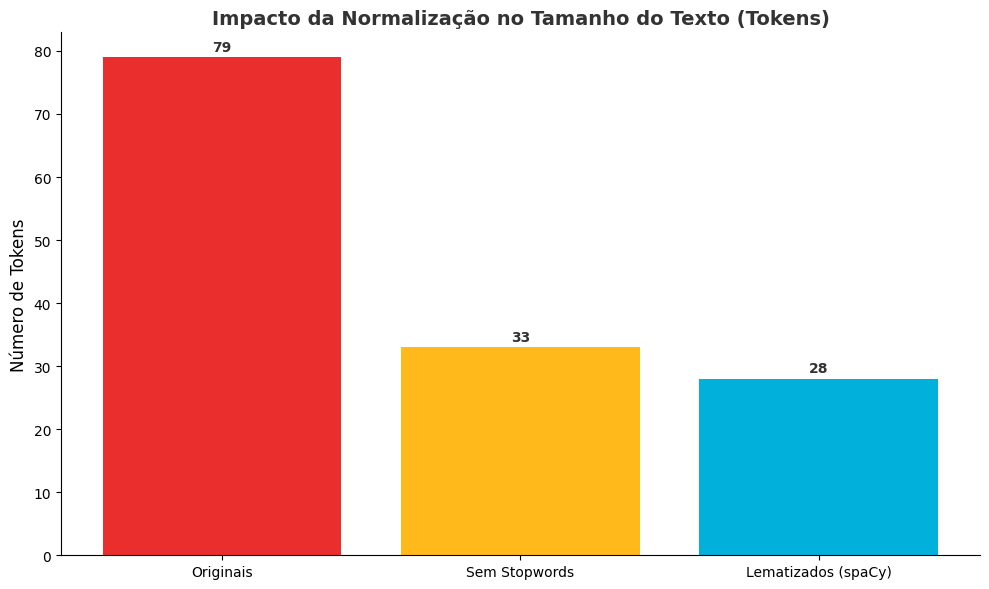

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.stem.snowball import SnowballStemmer
import nltk
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('rslp')

# 1. Carregar stopwords português
stop_words = set(stopwords.words('portuguese'))

# 2. Remover stopwords NLTK
tokens_limpos = [token.lower() for token in tokens_palavras
                 if token.lower() not in stop_words and token.isalpha()]

print(f"Tokens originais: {len(tokens_palavras)}")
print(f"Tokens sem stopwords: {len(tokens_limpos)}")
print(f"Redução: {((len(tokens_palavras) - len(tokens_limpos)) / len(tokens_palavras) * 100):.1f}%\n")

print(f"Primeiros 20 tokens limpos: {tokens_limpos[:20]}\n")

# 3. Stemming - RSLP (Portuguese Stemmer)
stemmer = RSLPStemmer()
tokens_stemmed = [stemmer.stem(token) for token in tokens_limpos]

print("STEMMING - Exemplos de redução:")
exemplos = [
    'computador', 'computadores', 'computação',
    'correr', 'correndo', 'corrida',
    'belo', 'beleza', 'belíssimo'
]
for palavra in exemplos:
    stem = stemmer.stem(palavra)
    print(f"  {palavra:15} → {stem}")

# 4. Lematização spaCy
doc = nlp(poema_exemplo)
tokens_lematizados = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

print("\nLEMATIZAÇÃO spaCy - Exemplos:")
exemplos_doc = nlp("computador computadores computação correr correndo corrida belo beleza")
for token in exemplos_doc:
    if token.is_alpha:
        print(f"  {token.text:15} → {token.lemma_}")

# 5. Comparação Stemming vs Lematização
print("\nCOMPARAÇÃO STEMMING vs LEMATIZAÇÃO:")
palavras_teste = ['correndo', 'correria', 'correr', 'corrida']
for palavra in palavras_teste:
    stem = stemmer.stem(palavra)
    token_doc = nlp(palavra)[0]
    lemma = token_doc.lemma_
    print(f"  {palavra:12} | Stem: {stem:10} | Lemma: {lemma}")

# 6. Frequência dos tokens processados
from collections import Counter
freq_stems = Counter(tokens_stemmed)
print("\nTop 20 STEMS mais frequentes:")
for stem, freq in freq_stems.most_common(20):
    print(f"  {stem:15} : {freq:3d}")

# 7. Visualização: Gráfico de impacto de normalização
print("\nGerando gráfico de impacto da normalização...")

plt.figure(figsize=(10, 6))
categorias = ['Originais', 'Sem Stopwords', 'Lematizados (spaCy)']
valores = [len(tokens_palavras), len(tokens_limpos), len(tokens_lematizados)]

# Definindo uma paleta de cor
cores_personalizadas = ['#ea2d2d', '#ffb91b', '#01b1dc']

# Criando o gráfico de barras
plt.bar(categorias, valores, color=cores_personalizadas)
plt.title('Impacto da Normalização no Tamanho do Texto (Tokens)', fontsize=14, fontweight='bold', color='#333333')
plt.ylabel('Número de Tokens', fontsize=12)

# Adicionando os números exatos em cima de cada barra
for i, v in enumerate(valores):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold', color='#333333')

# Removendo as bordas superior e direita do quadro do gráfico
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# Salvando a imagem em alta resolução
plt.savefig('impacto_normalizacao.png', dpi=150)
print("Gráfico 'impacto_normalizacao.png' salvo!")
plt.show()

### POS-Tagging (Part-of-Speech) e Análise Sintática (3)

POS-TAGGING NLTK - Primeiros 20 tokens:
   1. rosto        → NN
   2. hoje         → NN
   3. assim        → NN
   4. calmo        → NN
   5. assim        → NN
   6. triste       → NN
   7. assim        → NN
   8. magro        → NN
   9. olhos        → NN
  10. tão          → NN
  11. vazios       → NNS
  12. lábio        → VBP
  13. amargo       → JJ
  14. mãos         → NN
  15. força        → NN
  16. tão          → NN
  17. paradas      → NN
  18. frias        → NN
  19. mortas       → NNS
  20. coração      → VBP

POS-TAGGING spaCy - Primeiros 20 tokens:
   1. Eu           → PRON  (PRON)
   2. não          → ADV   (ADV)
   3. tinha        → VERB  (VERB)
   4. este         → DET   (DET)
   5. rosto        → NOUN  (NOUN)
   6. de           → ADP   (ADP)
   7. hoje         → ADV   (ADV)
  10. Assim        → ADV   (ADV)
  11. calmo        → ADJ   (ADJ)
  13. assim        → ADV   (ADV)
  14. triste       → VERB  (VERB)
  16. assim        → ADV   (ADV)
  17. magro        → ADJ   (ADJ)
 

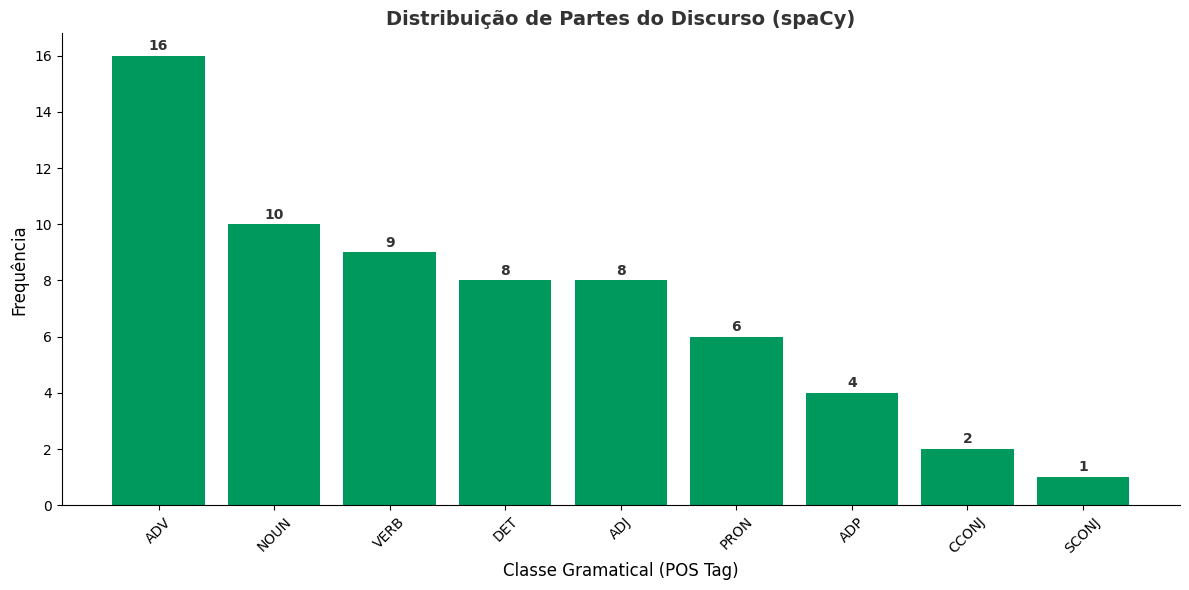

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. POS-Tagging NLTK
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('universal_tagset', quiet=True)

pos_tags_nltk = nltk.pos_tag(tokens_limpos)

print("POS-TAGGING NLTK - Primeiros 20 tokens:")
for i, (token, pos) in enumerate(pos_tags_nltk[:20]):
    print(f"  {i+1:2d}. {token:12} → {pos}")

# 2. POS-Tagging spaCy
doc = nlp(poema_exemplo)
print("\nPOS-TAGGING spaCy - Primeiros 20 tokens:")
for i, token in enumerate(list(doc)[:20]):
    if token.is_alpha:
        print(f"  {i+1:2d}. {token.text:12} → {token.pos_:5} ({token.tag_})")

# 3. Distribuição de POS tags
pos_dist_nltk = Counter([pos for token, pos in pos_tags_nltk])
print("\nDISTRIBUIÇÃO DE POS TAGS (NLTK):")
for pos, count in pos_dist_nltk.most_common(10):
    print(f"  {pos:10} : {count:3d}")

# 4. Distribuição de POS tags spaCy
pos_dist_spacy = Counter([token.pos_ for token in doc if token.is_alpha])
print("\nDISTRIBUIÇÃO DE POS TAGS (spaCy):")
for pos, count in pos_dist_spacy.most_common(10):
    print(f"  {pos:10} : {count:3d}")

# 5. Extrair palavras por tipo
print("\nPALAVRAS POR TIPO (spaCy):")
substantivos = [token.text for token in doc if token.pos_ == 'NOUN']
verbos = [token.text for token in doc if token.pos_ == 'VERB']
adjetivos = [token.text for token in doc if token.pos_ == 'ADJ']

print(f"  Substantivos ({len(substantivos)}): {substantivos[:10]}")
print(f"  Verbos ({len(verbos)}): {verbos[:10]}")
print(f"  Adjetivos ({len(adjetivos)}): {adjetivos[:10]}")

# 6. Visualizar distribuição
plt.figure(figsize=(12, 6))
pos_counts = Counter([token.pos_ for token in doc if token.is_alpha])

# Ordenando do maior para o menor para facilitar a análise
pos_ordenado = dict(sorted(pos_counts.items(), key=lambda item: item[1], reverse=True))

# Usando a cor verde especificada
cor_padrao = '#00995D'

# Criando o gráfico de barras
plt.bar(pos_ordenado.keys(), pos_ordenado.values(), color=cor_padrao)
plt.xlabel('Classe Gramatical (POS Tag)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição de Partes do Discurso (spaCy)', fontsize=14, fontweight='bold', color='#333333')
plt.xticks(rotation=45)

# Adicionando os números exatos em cima de cada barra
for i, v in enumerate(pos_ordenado.values()):
    # Ajuste o v + 0.1 se o número ficar muito colado ou distante da barra
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold', color='#333333')

# Removendo as bordas superior e direita do quadro do gráfico
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# Salvando a imagem em alta resolução
plt.savefig('pos_distribution.png', dpi=150)
print("\nGráfico 'pos_distribution.png' salvo!")
plt.show()

### Reconhecimento de Entidades Nomeadas (NER) (4)

In [ ]:
# 1. NER com spaCy
doc = nlp(poema_exemplo)

print("ENTIDADES IDENTIFICADAS (spaCy NER):")
if len(doc.ents) > 0:
    for i, ent in enumerate(doc.ents, 1):
        print(f"  {i}. '{ent.text}' → Tipo: {ent.label_} (Confiança: {ent.start_char}-{ent.end_char})")
else:
    print("  Nenhuma entidade nomeada encontrada neste poema.")

# 2. Distribuição de tipos de entidades
from collections import Counter
ent_types = Counter([ent.label_ for ent in doc.ents])
print(f"\nDISTRIBUIÇÃO DE ENTIDADES:")
for ent_type, count in ent_types.most_common():
    print(f"  {ent_type:10} : {count:2d}")

# 3. Extrair entidades por tipo
print("\nENTIDADES POR TIPO:")
for ent_type in ent_types.keys():
    entidades = [ent.text for ent in doc.ents if ent.label_ == ent_type]
    print(f"  {ent_type}: {entidades}")

# 4. NER em múltiplos poemas
print("\nNER EM MÚLTIPLOS POEMAS:")
heteronimos = ['Fernando Pessoa', 'Alberto Caeiro', 'Álvaro de Campos', 'Ricardo Reis']

df_pessoa = pd.read_csv('portuguese-poems.csv', encoding='utf-8')
df_pessoa = df_pessoa[df_pessoa['Author'].isin(heteronimos)]

ner_por_autor = {}
for autor in heteronimos:
    textos = df_pessoa[df_pessoa['Author'] == autor]['Content'].values
    ents_autor = []

    for texto in textos[:5]:  # Primeiros 5 poemas por autor
        doc_texto = nlp(str(texto))
        for ent in doc_texto.ents:
            ents_autor.append(ent.text)

    ner_por_autor[autor] = ents_autor
    print(f"\n{autor}:")
    if ents_autor:
        unique_ents = list(set(ents_autor))[:10]
        print(f"  Entidades encontradas: {unique_ents}")
    else:
        print(f"  Sem entidades nomeadas.")

# 5. Visualizar entidades com displacy (opcional)
from spacy import displacy

# Selecionar um texto com entidades
textos_com_ents = [str(texto) for texto in df_pessoa['Content'].values
                   if len(nlp(str(texto)).ents) > 0]

if textos_com_ents:
    doc_vis = nlp(textos_com_ents[0][:500])

    # Foi adicionado jupyter=False para forçar o retorno do HTML em string
    html = displacy.render(doc_vis, style='ent', page=True, jupyter=False)

    with open('ner_visualization.html', 'w', encoding='utf-8') as f:
        f.write(html)
    print("\nVisualização salva em: ner_visualization.html")

ENTIDADES IDENTIFICADAS (spaCy NER):
  1. 'Tão paradas e frias e mortas;
' → Tipo: MISC (Confiança: 157-187)
  2. 'Tão simples' → Tipo: MISC (Confiança: 262-273)

DISTRIBUIÇÃO DE ENTIDADES:
  MISC       :  2

ENTIDADES POR TIPO:
  MISC: ['Tão paradas e frias e mortas;\n', 'Tão simples']

NER EM MÚLTIPLOS POEMAS:

Fernando Pessoa:
  Entidades encontradas: ['serena', 'Quantos', 'Valeu', 'Brilha', 'Felizes', 'Bojador\nTem', 'Vejo', 'Vale', 'Teu', 'Portugal']

Alberto Caeiro:
  Sem entidades nomeadas.

Álvaro de Campos:
  Sem entidades nomeadas.

Ricardo Reis:
  Sem entidades nomeadas.

Visualização salva em: ner_visualization.html


### Análise de Dependências Sintáticas (5)

In [ ]:
# 1. Dependências sintáticas
doc = nlp(poema_exemplo)

print("ANÁLISE DE DEPENDÊNCIAS SINTÁTICAS:")
print("Relações entre palavras (Token → Dependência → Head):\n")

# Mostrar primeiras 20 relações
for i, token in enumerate(list(doc)[:20]):
    if token.head != token:  # Se não for a raiz
        print(f"  {token.text:12} →({token.dep_:8})→ {token.head.text}")

# 2. Árvore sintática - extração
print("\nÁRVORE SINTÁTICA (root):")
roots = [token for token in doc if token.head == token]
for root in roots[:3]:
    print(f"\n  Raiz: '{root.text}'")
    children = list(root.children)
    for child in children[:5]:
        print(f"    └─ {child.text} ({child.dep_})")

# 3. Extrair sintagmas nominais
print("\nSINTAGMAS NOMINAIS (Noun Chunks):")
noun_chunks = list(doc.noun_chunks)
for i, chunk in enumerate(noun_chunks[:10], 1):
    print(f"  {i}. '{chunk.text}' (head: {chunk.root.text})")

# 4. Análise de verbos e seus complementos
print("\nVERBOS E SEUS COMPLEMENTOS:")
for token in doc:
    if token.pos_ == "VERB":
        complements = [child.text for child in token.children
                       if child.dep_ in ['dobj', 'obj', 'attr', 'xcomp']]
        if complements:
            print(f"  Verbo: '{token.text}' → Complementos: {complements}")

# 5. Visualizar árvore sintática
from spacy import displacy

# Criar visualização
doc_sample = nlp(poema_exemplo[:300])
# CORREÇÃO: jupyter=False adicionado!
html = displacy.render(doc_sample, style='dep', page=True, manual=False, jupyter=False)
with open('syntax_tree.html', 'w', encoding='utf-8') as f:
    f.write(html)
print("\nVisualização salva com sucesso em: syntax_tree.html")

# 6. Métricas de complexidade sintática
print("\nCOMPLEXIDADE SINTÁTICA:")
num_tokens = len([token for token in doc if not token.is_punct])
num_deps = len(set([token.dep_ for token in doc]))
print(f"  Total de tokens (sem pontuação): {num_tokens}")
print(f"  Tipos diferentes de dependências: {num_deps}")
print(f"  Profundidade média: {sum([len(list(token.ancestors)) for token in doc]) / num_tokens:.2f}")

ANÁLISE DE DEPENDÊNCIAS SINTÁTICAS:
Relações entre palavras (Token → Dependência → Head):

  Eu           →(nsubj   )→ tinha
  não          →(advmod  )→ tinha
  este         →(det     )→ rosto
  rosto        →(obj     )→ tinha
  de           →(case    )→ hoje
  hoje         →(advmod  )→ rosto
  ,            →(punct   )→ calmo
  
            →(dep     )→ ,
  Assim        →(advmod  )→ calmo
  calmo        →(advcl   )→ tinha
  ,            →(punct   )→ calmo
  assim        →(advmod  )→ calmo
  triste       →(dep     )→ calmo
  ,            →(punct   )→ calmo
  assim        →(advmod  )→ magro
  magro        →(conj    )→ calmo
  ,            →(punct   )→ calmo
  
            →(dep     )→ ,
  Nem          →(cc      )→ olhos

ÁRVORE SINTÁTICA (root):

  Raiz: 'tinha'
    └─ Eu (nsubj)
    └─ não (advmod)
    └─ rosto (obj)
    └─ calmo (advcl)
    └─ olhos (obj)

  Raiz: 'tinha'
    └─ Eu (nsubj)
    └─ não (advmod)
    └─ mãos (obj)
    └─ paradas (advcl)

  Raiz: 'tinha'
    └─ Eu (nsubj)
 

### Pipeline Completo de PLN com Análise Comparativa (6)

In [ ]:
import time
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

# 1. PIPELINE NLTK COMPLETO
print("="*70)
print("PIPELINE NLTK")
print("="*70)

start = time.time()

# Tokenização
tokens = word_tokenize(poema_exemplo, language='portuguese')

# Limpeza
stop_words = set(stopwords.words('portuguese'))
tokens_limpos = [t.lower() for t in tokens if t.isalpha() and t.lower() not in stop_words]

# Stemming
stemmer = RSLPStemmer()
tokens_stemmed = [stemmer.stem(t) for t in tokens_limpos]

# POS Tagging
pos_tags = nltk.pos_tag(tokens_limpos)

nltk_time = time.time() - start

print(f"\nResultados NLTK:")
print(f"  Tokens originais: {len(tokens)}")
print(f"  Tokens limpos: {len(tokens_limpos)}")
print(f"  POS tags únicos: {len(set([p[1] for p in pos_tags]))}")
print(f"  Tempo de processamento: {nltk_time:.4f}s")

# 2. PIPELINE spaCy COMPLETO
print("\n" + "="*70)
print("PIPELINE spaCy")
print("="*70)

start = time.time()

doc = nlp(poema_exemplo)

# Extrair informações
tokens_spacy = [token.text for token in doc if not token.is_punct]
tokens_spacy_limpos = [token.text for token in doc if token.is_alpha and not token.is_stop]
lemmas = [token.lemma_ for token in doc if token.is_alpha]
pos_tags_spacy = set([token.pos_ for token in doc])
ents = len(doc.ents)

spacy_time = time.time() - start

print(f"\nResultados spaCy:")
print(f"  Tokens: {len(tokens_spacy)}")
print(f"  Tokens limpos: {len(tokens_spacy_limpos)}")
print(f"  Lemmas únicos: {len(set(lemmas))}")
print(f"  POS tags únicos: {len(pos_tags_spacy)}")
print(f"  Entidades encontradas: {ents}")
print(f"  Tempo de processamento: {spacy_time:.4f}s")

# 3. COMPARAÇÃO
print("\n" + "="*70)
print("COMPARAÇÃO")
print("="*70)
print(f"\nspaCy é {nltk_time/spacy_time:.1f}x mais rápido" if spacy_time < nltk_time
      else f"\nNLTK é {spacy_time/nltk_time:.1f}x mais rápido")

print("\nVANTAGENS E DESVANTAGENS:")
print("""
  NLTK:
    ✓ Simples e educacional
    ✓ Mais flexível para customização
    ✗ Mais lento
    ✗ Menos integrado

  spaCy:
    ✓ Mais rápido e eficiente
    ✓ Pipeline completo integrado
    ✓ Melhor para produção
    ✗ Menos flexível
    ✗ Requer modelos pré-treinados
""")

# 4. Aplicar em múltiplos textos
print("\nAPLICANDO PIPELINE EM MÚLTIPLOS POEMAS:")

# Lendo o arquivo correto do seu ambiente
df_pessoa = pd.read_csv('portuguese-poems.csv', encoding='utf-8')

resultados = []
for idx, row in df_pessoa.head(10).iterrows():
    doc = nlp(str(row['Content']))
    resultados.append({
        'Author': row['Author'],
        'num_tokens': len([t for t in doc if not t.is_punct]),
        'num_lemmas': len(set([t.lemma_ for t in doc if t.is_alpha])),
        'num_pos_types': len(set([t.pos_ for t in doc])),
        'num_entities': len(doc.ents)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

print("\nGerando planilha de resultados")
try:
    df_resultados.to_excel('resultados_pipelineEtapa6.xlsx', index=False)
    print("Planilha 'resultados_pipeline.xlsx' salva!")
except Exception as e:
    print(f"erro ao salvar o Excel: {e}")

PIPELINE NLTK

Resultados NLTK:
  Tokens originais: 79
  Tokens limpos: 33
  POS tags únicos: 4
  Tempo de processamento: 0.0083s

PIPELINE spaCy

Resultados spaCy:
  Tokens: 75
  Tokens limpos: 28
  Lemmas únicos: 42
  POS tags únicos: 11
  Entidades encontradas: 2
  Tempo de processamento: 0.0268s

COMPARAÇÃO

NLTK é 3.2x mais rápido

VANTAGENS E DESVANTAGENS:

  NLTK:
    ✓ Simples e educacional
    ✓ Mais flexível para customização
    ✗ Mais lento
    ✗ Menos integrado

  spaCy:
    ✓ Mais rápido e eficiente
    ✓ Pipeline completo integrado
    ✓ Melhor para produção
    ✗ Menos flexível
    ✗ Requer modelos pré-treinados


APLICANDO PIPELINE EM MÚLTIPLOS POEMAS:
                    Author  num_tokens  num_lemmas  num_pos_types  num_entities
          Cecília Meireles          75          42             11             2
           Fernando Pessoa          38          29             13             2
          Marina Colasanti         653         223             13             0
Ca

### Análise Completa e Relatório

ANÁLISE COMPLETA: POEMAS DE FERNANDO PESSOA E HETERÔNIMOS

RESUMO POR AUTOR:
           Autor  Num Poemas  Total Tokens  Vocabulário  POS Tipos  Entidades  Tokens/Poema
 Fernando Pessoa        2232        285560        20494         17      17059           127
  Alberto Caeiro           0             0            0          0          0             0
Álvaro de Campos           0             0            0          0          0             0
    Ricardo Reis           0             0            0          0          0             0

TERMOS MAIS COMUNS POR AUTOR

Fernando Pessoa - Top 10 lemmas:
  the             : 1459
  and             : 1410
  of              : 1202
  haver           : 1016
  vida            : 956
  eu              : 901
  to              : 887
  I               : 811
  The             : 805
  alma            : 780

Alberto Caeiro - Top 10 lemmas:

Álvaro de Campos - Top 10 lemmas:

Ricardo Reis - Top 10 lemmas:

DISTRIBUIÇÃO DE POS TAGS POR AUTOR

✓ Gráfico 'pos_by_a

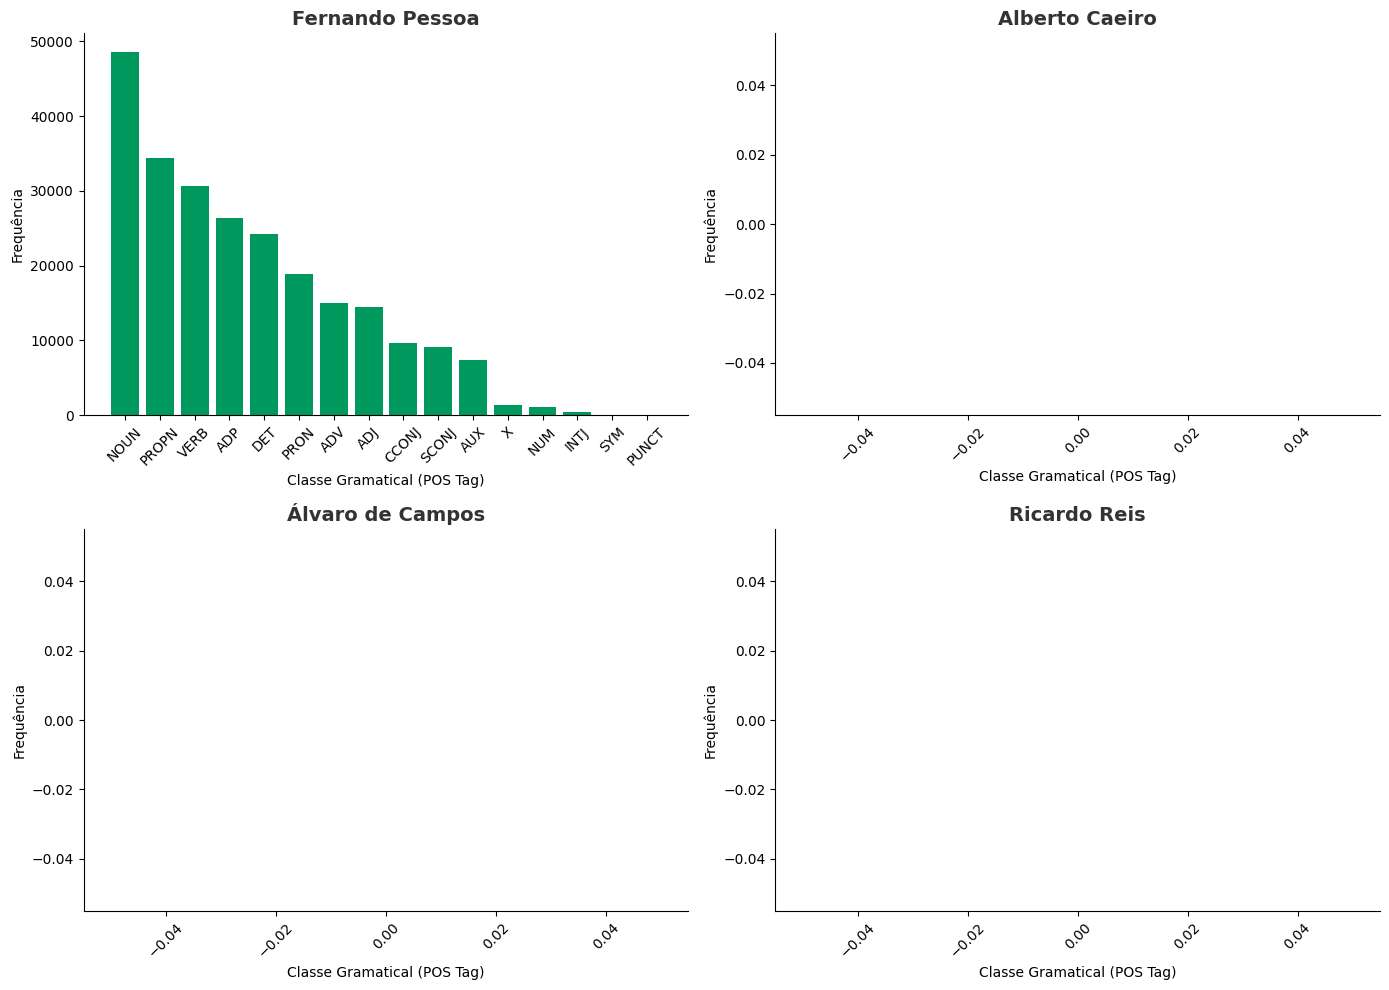


COMPLEXIDADE SINTÁTICA
           Autor Profundidade Media
 Fernando Pessoa               1.82
  Alberto Caeiro               0.00
Álvaro de Campos               0.00
    Ricardo Reis               0.00

SUMÁRIO FINAL

Total de poemas analisados: 2232
Autores: 4
Distribuição:
  - Fernando Pessoa: 2232 poemas
  - Alberto Caeiro: 0 poemas
  - Álvaro de Campos: 0 poemas
  - Ricardo Reis: 0 poemas

Ferramentas utilizadas:
  ✓ NLTK: Tokenização, Stemming, POS-Tagging
  ✓ spaCy: Pipeline completo, NER, análise sintática

Análises realizadas:
  ✓ Tokenização e análise estrutural
  ✓ Normalização e stemming
  ✓ POS-Tagging e análise sintática
  ✓ NER (Reconhecimento de Entidades)
  ✓ Dependências sintáticas
  ✓ Análise comparativa NLTK vs spaCy
  ✓ Análise completa por autor



In [24]:
# ANÁLISE COMPLETA - POEMAS PORTUGUESES

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# 1. Carregar dados
df = pd.read_csv('portuguese-poems.csv', encoding='utf-8')
heteronimos = ['Fernando Pessoa', 'Alberto Caeiro', 'Álvaro de Campos', 'Ricardo Reis']
df_pessoa = df[df['Author'].isin(heteronimos)]

# 2. Análise por autor
print("="*70)
print("ANÁLISE COMPLETA: POEMAS DE FERNANDO PESSOA E HETERÔNIMOS")
print("="*70)

analise_autores = []
for autor in heteronimos:
    textos = df_pessoa[df_pessoa['Author'] == autor]['Content'].values

    # Processar todos os textos
    todos_tokens = []
    todos_lemmas = []
    todos_pos = []
    todas_ents = []

    for texto in textos:
        doc = nlp(str(texto))
        todos_tokens.extend([t.text for t in doc if not t.is_punct])
        todos_lemmas.extend([t.lemma_ for t in doc if t.is_alpha])
        todos_pos.extend([t.pos_ for t in doc])
        todas_ents.extend([ent.label_ for ent in doc.ents])

    analise_autores.append({
        'Autor': autor,
        'Num Poemas': len(textos),
        'Total Tokens': len(todos_tokens),
        'Vocabulário': len(set(todos_lemmas)),
        'POS Tipos': len(set(todos_pos)),
        'Entidades': len(todas_ents),
        'Tokens/Poema': len(todos_tokens) // len(textos) if len(textos) > 0 else 0
    })

df_analise = pd.DataFrame(analise_autores)
print("\nRESUMO POR AUTOR:")
print(df_analise.to_string(index=False))

# 3. Termos mais comuns por autor
print("\n" + "="*70)
print("TERMOS MAIS COMUNS POR AUTOR")
print("="*70)

for autor in heteronimos:
    textos = df_pessoa[df_pessoa['Author'] == autor]['Content'].values
    todos_lemmas = []

    for texto in textos:
        doc = nlp(str(texto))
        todos_lemmas.extend([t.lemma_ for t in doc
                           if t.is_alpha and not t.is_stop])

    freq = Counter(todos_lemmas)
    print(f"\n{autor} - Top 10 lemmas:")
    for lemma, count in freq.most_common(10):
        print(f"  {lemma:15} : {count:3d}")

# 4. Análise POS por autor
print("\n" + "="*70)
print("DISTRIBUIÇÃO DE POS TAGS POR AUTOR")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cor_padrao = '#00995D'

for idx, autor in enumerate(heteronimos):
    textos = df_pessoa[df_pessoa['Author'] == autor]['Content'].values
    todos_pos = []

    for texto in textos:
        doc = nlp(str(texto))
        todos_pos.extend([t.pos_ for t in doc if t.is_alpha])

    pos_dist = Counter(todos_pos)
    # Ordenando
    pos_ordenado = dict(sorted(pos_dist.items(), key=lambda item: item[1], reverse=True))

    # Removida a borda
    axes[idx].bar(pos_ordenado.keys(), pos_ordenado.values(), color=cor_padrao)
    axes[idx].set_title(f'{autor}', fontsize=14, fontweight='bold', color='#333333')
    axes[idx].set_xlabel('Classe Gramatical (POS Tag)', fontsize=10)
    axes[idx].set_ylabel('Frequência', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

    # Removendo bordas superior e direita de cada subplot
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('pos_by_author.png', dpi=150)
print("\n✓ Gráfico 'pos_by_author.png' salvo com sucesso!")
plt.show()

# 5. Análise de complexidade
print("\n" + "="*70)
print("COMPLEXIDADE SINTÁTICA")
print("="*70)

complexidade = []
for autor in heteronimos:
    textos = df_pessoa[df_pessoa['Author'] == autor]['Content'].values

    prof_media = 0
    num_textos = 0

    for texto in textos:
        doc = nlp(str(texto))
        if len(doc) > 0:
            prof = sum([len(list(token.ancestors)) for token in doc]) / len(doc)
            prof_media += prof
            num_textos += 1

    if num_textos > 0:
        prof_media /= num_textos

    complexidade.append({
        'Autor': autor,
        'Profundidade Media': f"{prof_media:.2f}"
    })

df_complexidade = pd.DataFrame(complexidade)
print(df_complexidade.to_string(index=False))

# 6. Sumário estatístico
print("\n" + "="*70)
print("SUMÁRIO FINAL")
print("="*70)

print(f"""
Total de poemas analisados: {len(df_pessoa)}
Autores: {len(heteronimos)}
Distribuição:
  - Fernando Pessoa: {len(df_pessoa[df_pessoa['Author'] == 'Fernando Pessoa'])} poemas
  - Alberto Caeiro: {len(df_pessoa[df_pessoa['Author'] == 'Alberto Caeiro'])} poemas
  - Álvaro de Campos: {len(df_pessoa[df_pessoa['Author'] == 'Álvaro de Campos'])} poemas
  - Ricardo Reis: {len(df_pessoa[df_pessoa['Author'] == 'Ricardo Reis'])} poemas

Ferramentas utilizadas:
  ✓ NLTK: Tokenização, Stemming, POS-Tagging
  ✓ spaCy: Pipeline completo, NER, análise sintática

Análises realizadas:
  ✓ Tokenização e análise estrutural
  ✓ Normalização e stemming
  ✓ POS-Tagging e análise sintática
  ✓ NER (Reconhecimento de Entidades)
  ✓ Dependências sintáticas
  ✓ Análise comparativa NLTK vs spaCy
  ✓ Análise completa por autor
""")